In [1]:
import pandas as pd
import torch
import ast
import glob
import os
# import sys

# Ensure src is in sys.path
# sys.path.append("/home/jh/github_proj/FlareTorch/src")
from flaretorch.metrics.classification_metrics import ClassificationUQMetrics

/home/jh/miniforge3/envs/flaretorch/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/jh/github_proj/FlareTorch/src/flaretorch/datasets/flare_cls_datasets.py:521: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  @hydra.main(config_path="../../configs/", config_name="alexnet_helioviewer_config.yaml")


In [2]:
results_dir = "/home/jh/github_proj/FlareTorch/results/uc_results"
csv_files = glob.glob(os.path.join(results_dir, "*result_testset.csv"))
num_classes = 5

In [3]:
csv_files

['/home/jh/github_proj/FlareTorch/results/uc_results/ordinal_cqr_alpha0.1_result_testset.csv',
 '/home/jh/github_proj/FlareTorch/results/uc_results/aps_alpha0.1_result_testset.csv',
 '/home/jh/github_proj/FlareTorch/results/uc_results/oaps_alpha0.1_clsswiseTrue_result_testset.csv',
 '/home/jh/github_proj/FlareTorch/results/uc_results/lac_alpha0.1_clsswiseTrue_result_testset.csv',
 '/home/jh/github_proj/FlareTorch/results/uc_results/aps_alpha0.1_clsswiseTrue_result_testset.csv',
 '/home/jh/github_proj/FlareTorch/results/uc_results/oaps_alpha0.1_result_testset.csv']

In [4]:
csv_files = [
    '/home/jh/github_proj/FlareTorch/results/uc_results/ordinal_cqr_alpha0.1_result_testset.csv',
    '/home/jh/github_proj/FlareTorch/results/uc_results/oaps_alpha0.1_clsswiseTrue_result_testset.csv',
    '/home/jh/github_proj/FlareTorch/results/uc_results/lac_alpha0.1_clsswiseTrue_result_testset.csv',
    '/home/jh/github_proj/FlareTorch/results/uc_results/aps_alpha0.1_clsswiseTrue_result_testset.csv',]

method_results = {}

for file in csv_files:
    method_name = os.path.basename(file).replace('_result_testset.csv', '')
    print(f"Processing {method_name}")
    df = pd.read_csv(file)
    
    uq_metrics = ClassificationUQMetrics(num_classes=num_classes)
    
    for _, row in df.iterrows():
        pred_set = torch.tensor(ast.literal_eval(row['prediction_set']))
        target = torch.tensor(row['target'])
        uq_metrics.update(pred_set.unsqueeze(0), target.unsqueeze(0))
    
    method_results[method_name] = {k: v.item() for k, v in uq_metrics.compute().items()}

# Prepare data for plotting
df_results = pd.DataFrame.from_dict(method_results, orient='index')
df_results.index.name = 'Method'
df_results = df_results.reset_index()

Processing ordinal_cqr_alpha0.1
Processing oaps_alpha0.1_clsswiseTrue
Processing lac_alpha0.1_clsswiseTrue
Processing aps_alpha0.1_clsswiseTrue


In [5]:
df_results

,Method,marginal_coverage,avg_set_size,avg_sfs,avg_mdj,ccr
0,ordinal_cqr_alpha0.1,0.986060,2.929781,0.000000,0.000000,1.000000
1,oaps_alpha0.1_clsswiseTrue,0.924118,3.031272,0.866144,0.866144,0.602886
2,lac_alpha0.1_clsswiseTrue,0.962289,3.379408,0.723204,0.723204,0.725188
3,aps_alpha0.1_clsswiseTrue,0.958524,3.726883,0.400218,0.400218,0.758817


/tmp/ipykernel_27641/3754603689.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_results, x='Method', y=metric, palette='Set2')


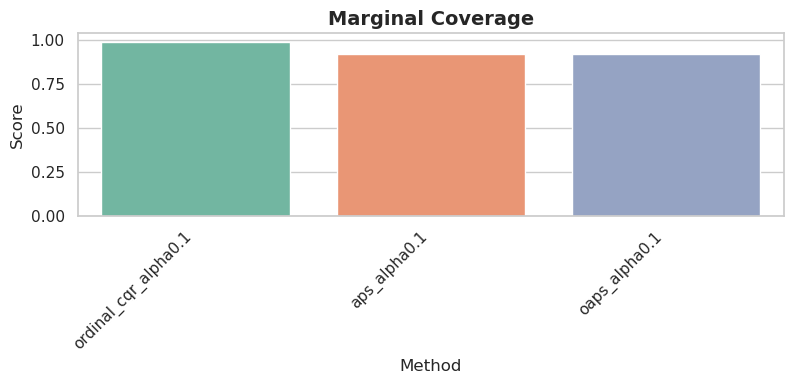

/tmp/ipykernel_27641/3754603689.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_results, x='Method', y=metric, palette='Set2')


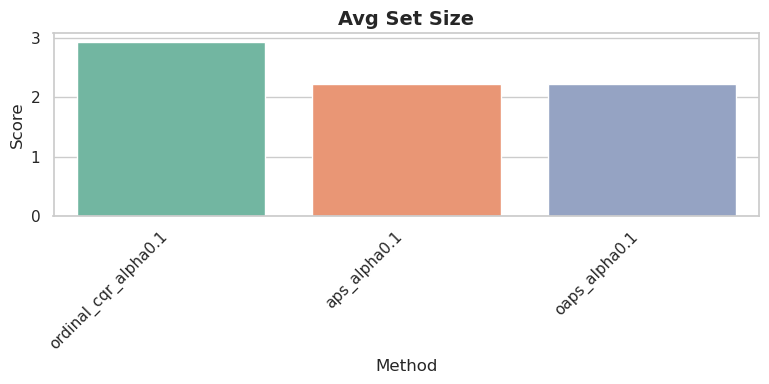

/tmp/ipykernel_27641/3754603689.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_results, x='Method', y=metric, palette='Set2')


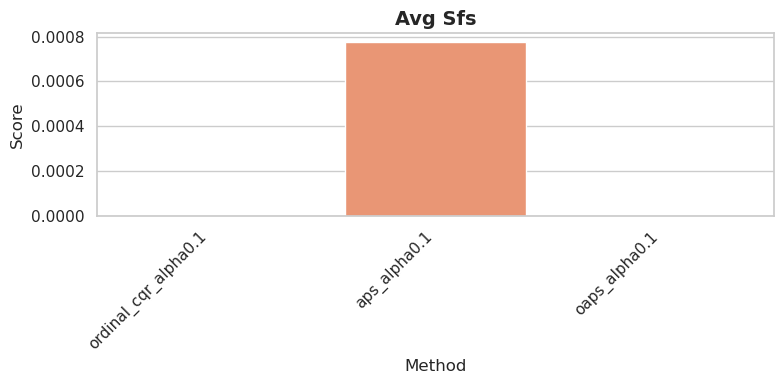

/tmp/ipykernel_27641/3754603689.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_results, x='Method', y=metric, palette='Set2')


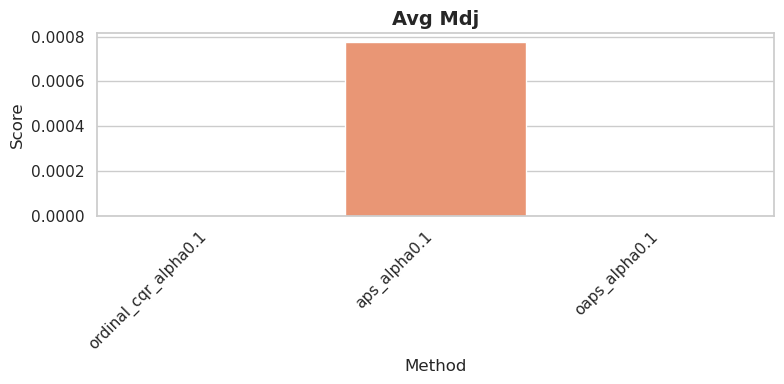

/tmp/ipykernel_27641/3754603689.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_results, x='Method', y=metric, palette='Set2')


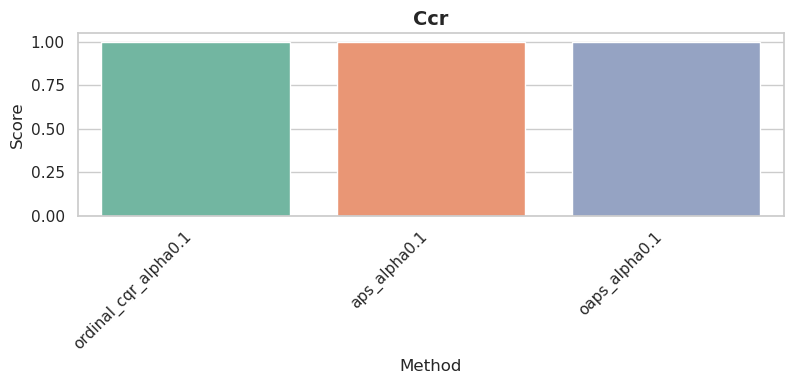

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", font="sans-serif")
plt.rcParams["font.family"] = "sans-serif"

metrics_to_plot = ['marginal_coverage', 'avg_set_size', 'avg_sfs', 'avg_mdj', 'ccr']

for metric in metrics_to_plot:
    plt.figure(figsize=(8, 4))
    sns.barplot(data=df_results, x='Method', y=metric, palette='Set2')
    plt.title(f'{metric.replace("_", " ").title()}', fontsize=14, fontweight='bold')
    plt.ylabel('Score', fontsize=12)
    plt.xlabel('Method', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [6]:
method_class_data = []

for file in csv_files:
    method_name = os.path.basename(file).replace('_result_testset.csv', '')
    print(f"Processing per-class metrics for {method_name}")
    df = pd.read_csv(file)
    # num_classes = len(ast.literal_eval(df['probs'][0]))
    unique_targets = sorted(df['target'].unique())
    
    for target_val in unique_targets:
        df_class = df[df['target'] == target_val]
        uq_metrics = ClassificationUQMetrics(num_classes=num_classes)
        for _, row in df_class.iterrows():
            pred_set = torch.tensor(ast.literal_eval(row['prediction_set']))
            target = torch.tensor(row['target'])
            uq_metrics.update(pred_set.unsqueeze(0), target.unsqueeze(0))
        
        res = {k: v.item() for k, v in uq_metrics.compute().items()}
        res['Method'] = method_name
        res['Target Class'] = target_val
        method_class_data.append(res)

df_class_results = pd.DataFrame(method_class_data)

Processing per-class metrics for ordinal_cqr_alpha0.1
Processing per-class metrics for aps_alpha0.1
Processing per-class metrics for oaps_alpha0.1


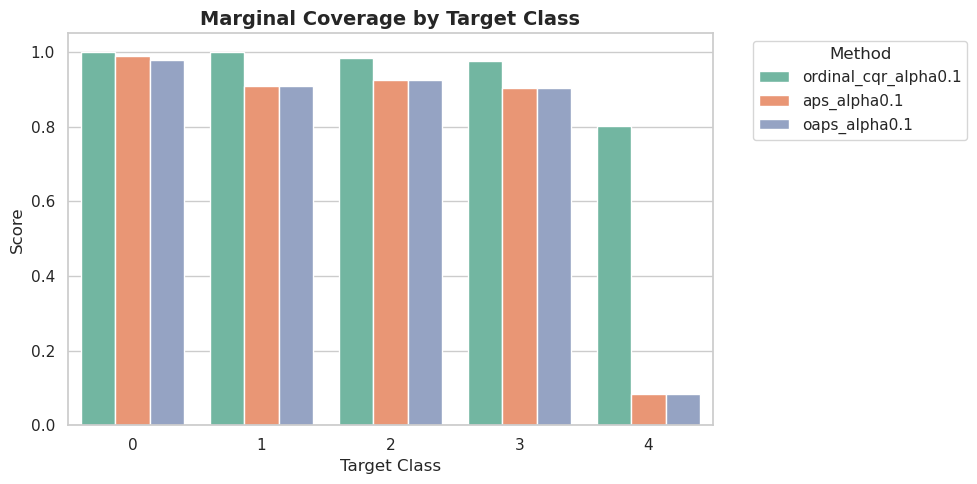

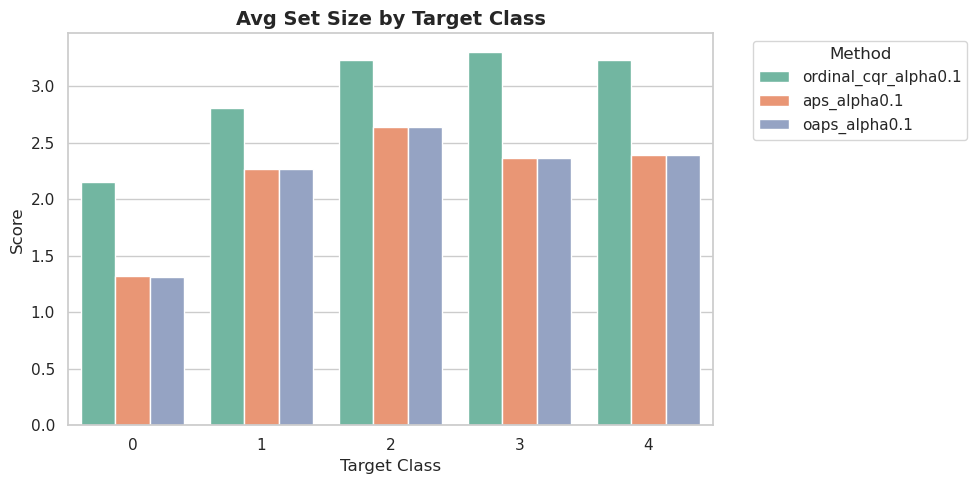

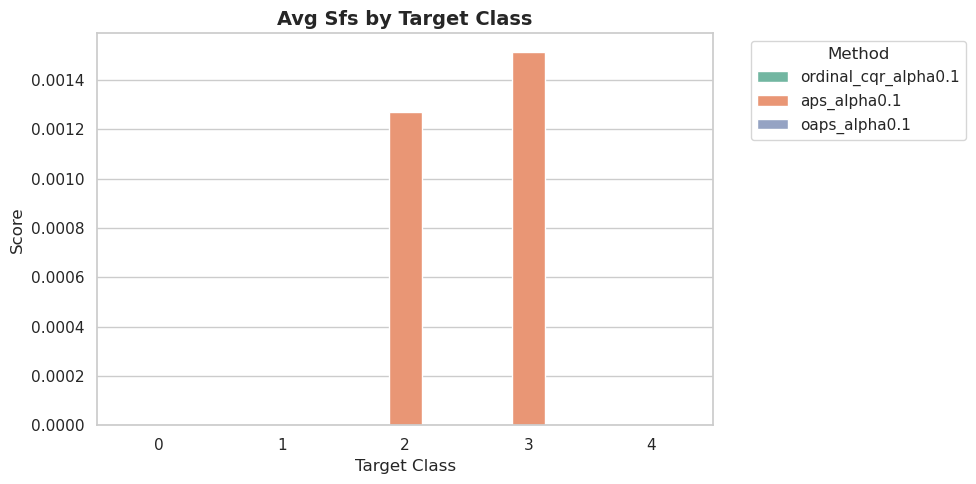

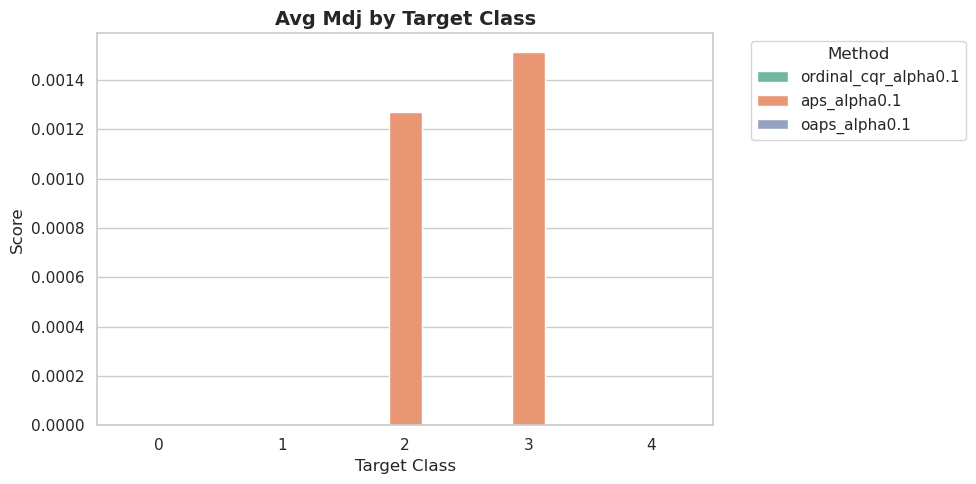

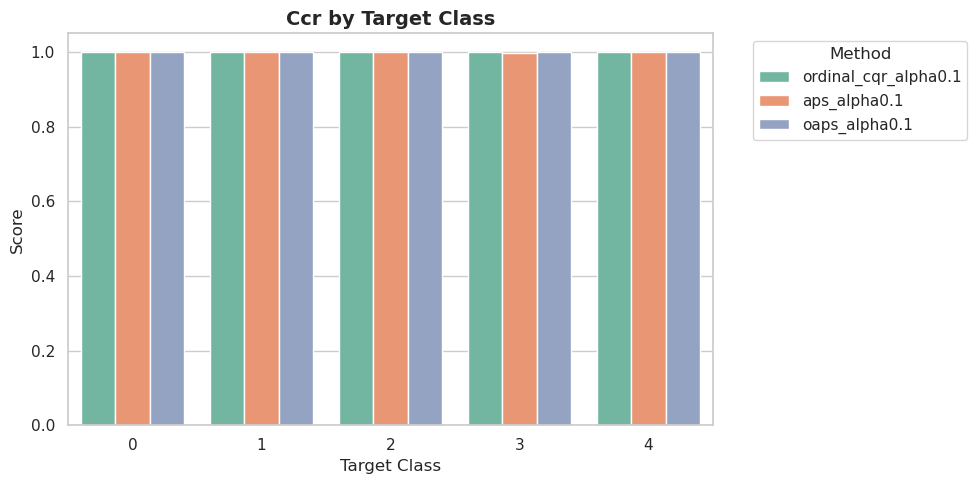

In [7]:
for metric in metrics_to_plot:
    plt.figure(figsize=(10, 5))
    sns.barplot(data=df_class_results, x='Target Class', y=metric, hue='Method', palette='Set2')
    plt.title(f'{metric.replace("_", " ").title()} by Target Class', fontsize=14, fontweight='bold')
    plt.ylabel('Score', fontsize=12)
    plt.xlabel('Target Class', fontsize=12)
    plt.legend(title='Method', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()